In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
#import LanusStats  as ls
import soccerdata as sd
import ScraperFC as sfc
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity


[09/15/26 19:45:43] INFO     No custom team name replacements found. You can configure these in       ]8;id=1554962;file://C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\soccerdata\_config.py\_config.py]8;;\:]8;id=1554963;file://C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\soccerdata\_config.py#91\91]8;;\
                             C:\Users\tela\soccerdata\config\teamname_replacements.json.                           

                    INFO     No custom league dict found. You can configure additional leagues in    ]8;id=1554969;file://C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\soccerdata\_config.py\_config.py]8;;\:]8;id=1554970;file://C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\soccerdata\_config.py#189\189]8;;\
                             C:\Users\tela\soccerdata\config\league_dict.json.                                     

In [2]:

# fbref = ls.Fbref()

# print(ls.get_available_leagues('Fbref'))
# jugadores= fbref.get_all_player_season_stats("La Liga", "2024-2025", save_csv=False)
# #print(jugadores.head())
# print(jugadores.dtype())

fbref = sd.FBref('ENG-Premier League', '2024')

# Fetch data
games = fbref.read_schedule()
team_season_stats = fbref.read_team_season_stats(stat_type="standard")
player_season_stats = fbref.read_player_season_stats(stat_type="standard")
print(player_season_stats.head())

[09/15/26 19:45:47] INFO     Saving cached data to C:\Users\tela\soccerdata\data\FBref               ]8;id=1554977;file://C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=1554978;file://C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\soccerdata\_common.py#250\250]8;;\

[09/15/26 19:45:52] WARNING  C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3 warnings.py:110
                             .13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\so                
                             ccerdata\fbref.py:171: FutureWarning: The behavior of DataFrame                       
                             concatenation with empty or all-NA entries is deprecated. In a future                 
                             version, this will no longer exclude empty or all-NA columns when                     
                             determining the result dtypes. To retain the old behavior, exclude the                
                             relevant entries before the concat operation.                                         
                               pd.concat(dfs)                                                                      
                                                                                                                   

[09/15/26 19:45:53] WARNING  C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3 warnings.py:110
                             .13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\so                
                             ccerdata\fbref.py:171: FutureWarning: The behavior of DataFrame                       
                             concatenation with empty or all-NA entries is deprecated. In a future                 
                             version, this will no longer exclude empty or all-NA columns when                     
                             determining the result dtypes. To retain the old behavior, exclude the                
                             relevant entries before the concat operation.                                         
                               pd.concat(dfs)                                                                      
                                                                                                                   

                    WARNING  C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3 warnings.py:110
                             .13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\so                
                             ccerdata\fbref.py:171: FutureWarning: The behavior of DataFrame                       
                             concatenation with empty or all-NA entries is deprecated. In a future                 
                             version, this will no longer exclude empty or all-NA columns when                     
                             determining the result dtypes. To retain the old behavior, exclude the                
                             relevant entries before the concat operation.                                         
                               pd.concat(dfs)                                                                      
                                                                                                                   

                                                nation    pos age  born  \
                                                                          
league             season team    player                                  
ENG-Premier League 2425   Arsenal Ben White        ENG     DF  26  1997   
                                  Bukayo Saka      ENG  FW,MF  22  2001   
                                  David Raya       ESP     GK  28  1995   
                                  Declan Rice      ENG     MF  25  1999   
                                  Ethan Nwaneri    ENG  FW,MF  17  2007   

                                                Playing Time               \
                                                          MP Starts   Min   
league             season team    player                                    
ENG-Premier League 2425   Arsenal Ben White               17     13  1198   
                                  Bukayo Saka             25     20  1729   
              

In [3]:
print(player_season_stats.columns)

MultiIndex([(        'nation',       ''),
            (           'pos',       ''),
            (           'age',       ''),
            (          'born',       ''),
            (  'Playing Time',     'MP'),
            (  'Playing Time', 'Starts'),
            (  'Playing Time',    'Min'),
            (  'Playing Time',    '90s'),
            (   'Performance',    'Gls'),
            (   'Performance',    'Ast'),
            (   'Performance',    'G+A'),
            (   'Performance',   'G-PK'),
            (   'Performance',     'PK'),
            (   'Performance',  'PKatt'),
            (   'Performance',   'CrdY'),
            (   'Performance',   'CrdR'),
            ('Per 90 Minutes',    'Gls'),
            ('Per 90 Minutes',    'Ast'),
            ('Per 90 Minutes',    'G+A'),
            ('Per 90 Minutes',   'G-PK'),
            ('Per 90 Minutes', 'G+A-PK')],
           )


In [4]:
player_season_stats.head()

nation    pos age  born  \
                                                                          
league             season team    player                                  
ENG-Premier League 2425   Arsenal Ben White        ENG     DF  26  1997   
                                  Bukayo Saka      ENG  FW,MF  22  2001   
                                  David Raya       ESP     GK  28  1995   
                                  Declan Rice      ENG     MF  25  1999   
                                  Ethan Nwaneri    ENG  FW,MF  17  2007   

                                                Playing Time               \
                                                          MP Starts   Min   
league             season team    player                                    
ENG-Premier League 2425   Arsenal Ben White               17     13  1198   
                                  Bukayo Saka             25     20  1729   
                                  David Raya              38     38  3420   
                                  Declan Rice             35     33  2825   
                                  Ethan Nwaneri           26     11   895   

                                                      Performance      ...  \
                                                  90s         Gls Ast  ...   
league             season team    player                               ...   
ENG-Premier League 2425   Arsenal Ben White      13.3           0   2  ...   
                                  Bukayo Saka    19.2           6  10  ...   
                                  David Raya     38.0           0   0  ...   
                                  Declan Rice    31.4           4   7  ...   
                                  Ethan Nwaneri   9.9           4   2  ...   

                                                                         \
                                                G-PK PK PKatt CrdY CrdR   
league             season team    player                                  
ENG-Premier League 2425   Arsenal Ben White        0  0     0    2    0   
                                  Bukayo Saka      5  1     1    3    0   
                                  David Raya       0  0     0    3    0   
                                  Declan Rice      4  0     0    7    1   
                                  Ethan Nwaneri    4  0     0    1    0   

                                                Per 90 Minutes              \
                                                           Gls   Ast   G+A   
league             season team    player                                     
ENG-Premier League 2425   Arsenal Ben White                0.0  0.15  0.15   
                                  Bukayo Saka             0.31  0.52  0.83   
                                  David Raya               0.0   0.0   0.0   
                                  Declan Rice             0.13  0.22  0.35   
                                  Ethan Nwaneri            0.4   0.2   0.6   

                                                              
                                                 G-PK G+A-PK  
league             season team    player                      
ENG-Premier League 2425   Arsenal Ben White       0.0   0.15  
                                  Bukayo Saka    0.26   0.78  
                                  David Raya      0.0    0.0  
                                  Declan Rice    0.13   0.35  
                                  Ethan Nwaneri   0.4    0.6  

[5 rows x 21 columns]

In [6]:
print(player_season_stats[(player_season_stats["team"]=="Manchester City")])

KeyError: 'team'

In [ ]:
player_season_stats_shooting = fbref.read_player_season_stats(stat_type="shooting")
player_season_stats_playing_time = fbref.read_player_season_stats(stat_type="playing_time")
player_season_stats_keeper = fbref.read_player_season_stats(stat_type="keeper")
player_season_stats_misc = fbref.read_player_season_stats(stat_type="misc")

print(player_season_stats.columns, player_season_stats_shooting.columns, player_season_stats_playing_time.columns, player_season_stats_keeper.columns, player_season_stats_misc.columns)




[09/15/26 19:48:30] WARNING  C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3 warnings.py:110
                             .13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\so                
                             ccerdata\fbref.py:171: FutureWarning: The behavior of DataFrame                       
                             concatenation with empty or all-NA entries is deprecated. In a future                 
                             version, this will no longer exclude empty or all-NA columns when                     
                             determining the result dtypes. To retain the old behavior, exclude the                
                             relevant entries before the concat operation.                                         
                               pd.concat(dfs)                                                                      
                                                                                                                   

                    WARNING  C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3 warnings.py:110
                             .13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\so                
                             ccerdata\fbref.py:171: FutureWarning: The behavior of DataFrame                       
                             concatenation with empty or all-NA entries is deprecated. In a future                 
                             version, this will no longer exclude empty or all-NA columns when                     
                             determining the result dtypes. To retain the old behavior, exclude the                
                             relevant entries before the concat operation.                                         
                               pd.concat(dfs)                                                                      
                                                                                                                   

[09/15/26 19:48:31] WARNING  C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3 warnings.py:110
                             .13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\so                
                             ccerdata\fbref.py:171: FutureWarning: The behavior of DataFrame                       
                             concatenation with empty or all-NA entries is deprecated. In a future                 
                             version, this will no longer exclude empty or all-NA columns when                     
                             determining the result dtypes. To retain the old behavior, exclude the                
                             relevant entries before the concat operation.                                         
                               pd.concat(dfs)                                                                      
                                                                                                                   

In [ ]:
print(player_season_stats.columns, player_season_stats_shooting.columns, player_season_stats_playing_time.columns, player_season_stats_keeper.columns, player_season_stats_misc.columns)


MultiIndex([(        'nation',       ''),
            (           'pos',       ''),
            (           'age',       ''),
            (          'born',       ''),
            (  'Playing Time',     'MP'),
            (  'Playing Time', 'Starts'),
            (  'Playing Time',    'Min'),
            (  'Playing Time',    '90s'),
            (   'Performance',    'Gls'),
            (   'Performance',    'Ast'),
            (   'Performance',    'G+A'),
            (   'Performance',   'G-PK'),
            (   'Performance',     'PK'),
            (   'Performance',  'PKatt'),
            (   'Performance',   'CrdY'),
            (   'Performance',   'CrdR'),
            ('Per 90 Minutes',    'Gls'),
            ('Per 90 Minutes',    'Ast'),
            ('Per 90 Minutes',    'G+A'),
            ('Per 90 Minutes',   'G-PK'),
            ('Per 90 Minutes', 'G+A-PK')],
           ) MultiIndex([(  'nation',       ''),
            (     'pos',       ''),
            (     'age',       '

In [ ]:
print(f"Indices: {player_season_stats.index}")
print(f"Columnas {player_season_stats.columns}")

Indices: MultiIndex([('ENG-Premier League', '2526', 'Arsenal',          'Ben White'),
            ('ENG-Premier League', '2526', 'Arsenal',        'Bukayo Saka'),
            ('ENG-Premier League', '2526', 'Arsenal', 'Christian Nørgaard'),
            ('ENG-Premier League', '2526', 'Arsenal', 'Cristhian Mosquera'),
            ('ENG-Premier League', '2526', 'Arsenal',         'David Raya'),
            ('ENG-Premier League', '2526', 'Arsenal',        'Declan Rice'),
            ('ENG-Premier League', '2526', 'Arsenal',       'Eberechi Eze'),
            ('ENG-Premier League', '2526', 'Arsenal',      'Ethan Nwaneri'),
            ('ENG-Premier League', '2526', 'Arsenal',      'Gabriel Jesus'),
            ('ENG-Premier League', '2526', 'Arsenal',  'Gabriel Magalhães'),
            ...
            ('ENG-Premier League', '2526',  'Wolves',         'Pedro Lima'),
            ('ENG-Premier League', '2526',  'Wolves',      'Rodrigo Gomes'),
            ('ENG-Premier League', '2526',  'Wolves

In [ ]:
claves = ["player", "nation", "born", "pos", "age"]

dfs = [
    player_season_stats,
    player_season_stats_shooting,
    player_season_stats_playing_time,
    player_season_stats_keeper,
    player_season_stats_misc
]

for df_temp in dfs:
    if "player" not in df_temp.columns:
        df_temp.reset_index(inplace=True)

for df_temp in dfs:
    if isinstance(df_temp.columns, pd.MultiIndex):
        df_temp.columns = [
            f"{col[0]}_{col[1]}" if col[1] != "" else col[0]
            for col in df_temp.columns
        ]

columnas_repetidas = ["team", "season", "league"]

for df_temp in dfs[1:]:
    df_temp.drop(
        columns=[col for col in columnas_repetidas if col in df_temp.columns],
        inplace=True
    )
    
df = player_season_stats.merge(
    player_season_stats_shooting,
    on=claves,
    how="left"
)

df = df.merge(
    player_season_stats_playing_time,
    on=claves,
    how="left"
)

df = df.merge(
    player_season_stats_keeper,
    on=claves,
    how="left"
)

df = df.merge(
    player_season_stats_misc,
    on=claves,
    how="left"
)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 665 entries, 0 to 664
Data columns (total 85 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   league                 665 non-null    object 
 1   season                 665 non-null    object 
 2   team                   665 non-null    string 
 3   player                 665 non-null    string 
 4   nation                 665 non-null    string 
 5   pos                    665 non-null    string 
 6   age                    665 non-null    Int64  
 7   born                   665 non-null    Int64  
 8   Playing Time_MP_x      665 non-null    Int64  
 9   Playing Time_Starts_x  665 non-null    Int64  
 10  Playing Time_Min_x     665 non-null    Int64  
 11  Playing Time_90s_x     665 non-null    Float64
 12  Performance_Gls        665 non-null    Int64  
 13  Performance_Ast        665 non-null    Int64  
 14  Performance_G+A        665 non-null    Int64  
 15  Perfor

In [ ]:
print(df[(df["team"]=="Manchester City")])

                 league season             team                player nation  \
387  ENG-Premier League   2526  Manchester City    Abdukodir Khusanov    UZB   
388  ENG-Premier League   2526  Manchester City       Antoine Semenyo    GHA   
389  ENG-Premier League   2526  Manchester City        Bernardo Silva    POR   
390  ENG-Premier League   2526  Manchester City         Divine Mukasa    ENG   
391  ENG-Premier League   2526  Manchester City        Erling Haaland    NOR   
392  ENG-Premier League   2526  Manchester City  Gianluigi Donnarumma    ITA   
393  ENG-Premier League   2526  Manchester City        James Trafford    ENG   
394  ENG-Premier League   2526  Manchester City           Jeremy Doku    BEL   
395  ENG-Premier League   2526  Manchester City           John Stones    ENG   
396  ENG-Premier League   2526  Manchester City        Joško Gvardiol    CRO   
397  ENG-Premier League   2526  Manchester City            Marc Guéhi    ENG   
398  ENG-Premier League   2526  Manchest

## Momento de intentar reducir la dimensionalidad, dando prioridad a las variables más relevantes

**Variables consideradas mas relevantes, eliminando redundancias a la vez, acabamos con 22 variables**

In [9]:
variables_pca = [
    # Producción ofensiva
    "Per 90 Minutes_Gls",
    "Per 90 Minutes_Ast",
    "Per 90 Minutes_G+A",
    "Per 90 Minutes_G-PK",
    "Per 90 Minutes_G+A-PK",
    
    # Tiros
    "Standard_Sh/90",
    "Standard_SoT/90",
    "Standard_SoT%",
    "Standard_G/Sh",
    "Standard_G/SoT",
    
    # Tiempo de juego
    "Playing Time_Min%",
    
    # Equipo
    "Team Success_PPM",
    "Team Success_+/-90",
    "Team Success_On-Off",
    
    # Defensa
    "Performance_Fls",
    "Performance_Fld",
    "Performance_Off",
    "Performance_Crs",
    "Performance_Int",
    "Performance_TklW",
    
    # Disciplina
    "Performance_CrdY_y",
    "Performance_CrdR_y"
]

In [10]:
df_sin_porteros = df[df["pos"] != "GK"].copy()


FILTRAR_POR_POSICION = False  
POSICION_FILTRO = "FW"        # posición que debe contener el jugador (ej. "FW", "MF", "DF")

if FILTRAR_POR_POSICION:
    df_sin_porteros = df_sin_porteros[
        df_sin_porteros["pos"].str.contains(POSICION_FILTRO, na=False)
    ].copy()

df_pca_data = df_sin_porteros[variables_pca].copy()

In [11]:
df_num = df_pca_data.select_dtypes(include=['number'])
df_num.index = df_sin_porteros['player']

In [12]:

UMBRAL_NAN = 10

na_counts = df_num.isna().sum()
cols_pocos_na = na_counts[(na_counts > 0) & (na_counts < UMBRAL_NAN)].index.tolist()
cols_muchos_na = na_counts[na_counts >= UMBRAL_NAN].index.tolist()

print(f"Columnas con <{UMBRAL_NAN} NaN (se eliminan jugadores): {cols_pocos_na}")
print(f"Columnas con >={UMBRAL_NAN} NaN (se imputa la moda): {cols_muchos_na}")

df_num = df_num.dropna(subset=cols_pocos_na)

for col in cols_muchos_na:
    moda = df_num[col].mode(dropna=True)[0]
    df_num[col] = df_num[col].fillna(moda)

print(f"Jugadores restantes tras el tratamiento de nulos: {df_num.shape[0]}")

Columnas con <10 NaN (se eliminan jugadores): ['Playing Time_Min%', 'Team Success_PPM', 'Team Success_+/-90', 'Team Success_On-Off']
Columnas con >=10 NaN (se imputa la moda): ['Standard_SoT%', 'Standard_G/Sh', 'Standard_G/SoT']
Jugadores restantes tras el tratamiento de nulos: 622


In [13]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_num)

In [41]:
pca = PCA(n_components=10)
df_pca= pca.fit_transform(df_scaled)

print(pca.n_components_)

10


In [42]:
pesos = pd.DataFrame(
    pca.components_.T, 
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])],
    index= df_num.columns
)
print(pesos)

                            PC1       PC2       PC3       PC4       PC5  \
Per 90 Minutes_Gls     0.241122  0.321769 -0.014566 -0.041829  0.048514   
Per 90 Minutes_Ast     0.068863  0.109440 -0.053547  0.592861 -0.198626   
Per 90 Minutes_G+A     0.230819  0.318907 -0.044754  0.336028 -0.085418   
Per 90 Minutes_G-PK    0.235278  0.321971 -0.012315 -0.030216  0.041145   
Per 90 Minutes_G+A-PK  0.225706  0.318313 -0.043152  0.348022 -0.092343   
Standard_Sh/90         0.045591  0.207010 -0.003172 -0.032089  0.482764   
Standard_SoT/90        0.210772  0.284617 -0.021254 -0.147216  0.323283   
Standard_SoT%          0.199181  0.060365 -0.051836 -0.296209  0.019989   
Standard_G/Sh          0.251539  0.143942 -0.019108 -0.353531 -0.425541   
Standard_G/SoT         0.245442  0.092036 -0.000672 -0.314447 -0.466984   
Playing Time_Min%      0.318259 -0.251484 -0.024256  0.018997  0.054358   
Team Success_PPM       0.089081 -0.033155  0.308448  0.027632 -0.022411   
Team Success_+/-90     0.

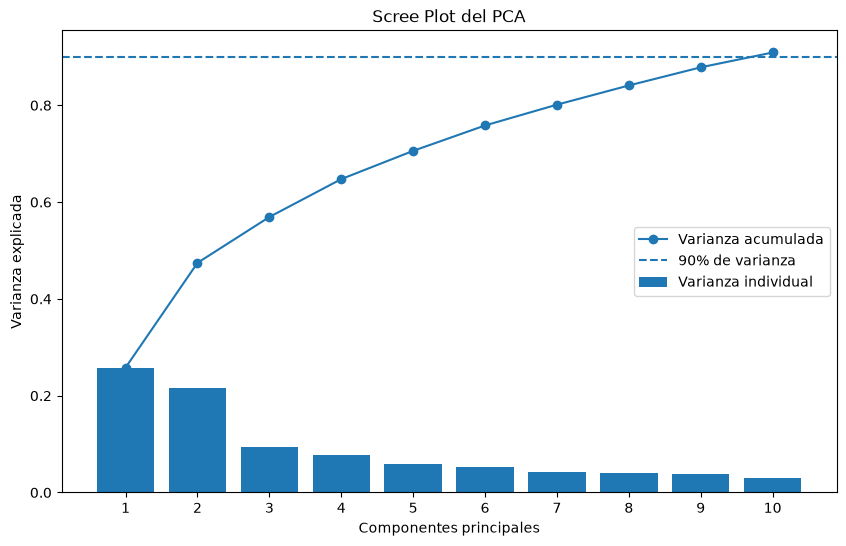

In [43]:

varianza = pca.explained_variance_ratio_
acumulada = np.cumsum(varianza)

plt.figure(figsize=(10, 6))

plt.bar(
    range(1, len(varianza) + 1),
    varianza,
    label="Varianza individual"
)

plt.plot(
    range(1, len(acumulada) + 1),
    acumulada,
    marker="o",
    label="Varianza acumulada"
)

plt.axhline(
    0.90,
    linestyle="--",
    label="90% de varianza"
)

plt.xlabel("Componentes principales")
plt.ylabel("Varianza explicada")
plt.title("Scree Plot del PCA")
plt.xticks(range(1, len(varianza) + 1))
plt.legend()

plt.show()

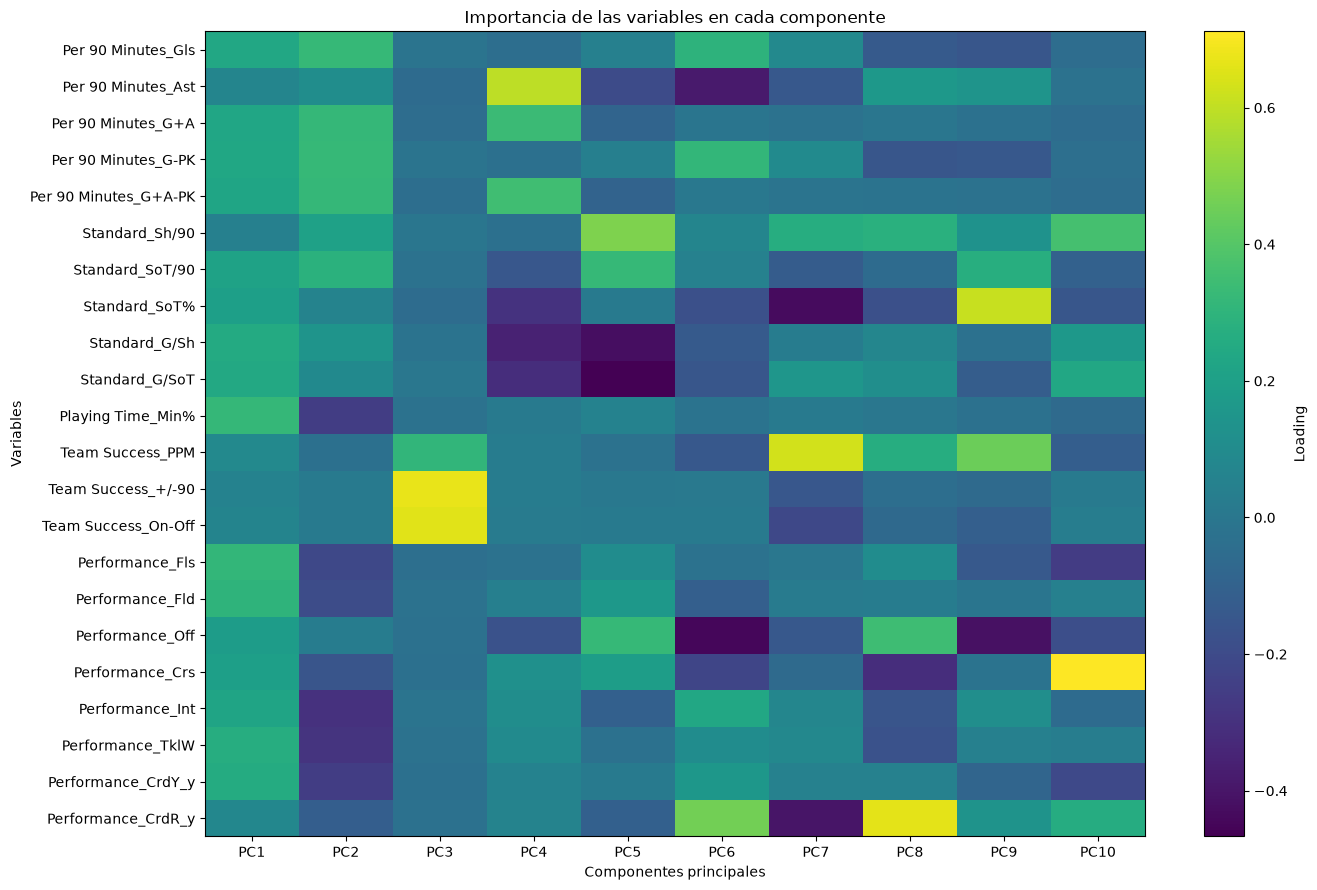

In [44]:
plt.figure(figsize=(14, 9))

plt.imshow(
    pesos,
    aspect="auto"
)

plt.colorbar(label="Loading")

plt.xticks(
    range(len(pesos.columns)),
    pesos.columns
)

plt.yticks(
    range(len(pesos.index)),
    pesos.index
)

plt.xlabel("Componentes principales")
plt.ylabel("Variables")
plt.title("Importancia de las variables en cada componente")

plt.tight_layout()
plt.show()

## Unificación de datasets, junto a ELO  y valor contractual del jugador


In [45]:
clubelo = sd.ClubElo()


[09/15/26 18:15:26] INFO     Saving cached data to C:\Users\tela\soccerdata\data\ClubElo             ]8;id=9426246;file://C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=9426247;file://C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\soccerdata\_common.py#250\250]8;;\

[2026-09-15 18:15:26] INFO     TLSLibrary:_load_library:397 - Successfully loaded TLS library: C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tls_requests\bin\tls-client-xgo-1.13.1-windows-amd64.dll


                    INFO     Successfully loaded TLS library:                                      ]8;id=9426254;file://C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tls_requests\models\libraries.py\libraries.py]8;;\:]8;id=9426255;file://C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tls_requests\models\libraries.py#397\397]8;;\
                             C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.                 
                             3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\                 
                             tls_requests\bin\tls-client-xgo-1.13.1-windows-amd64.dll                              

Definimos 1 de junio de 2026 como el final de la temporada 25/26

In [46]:
current_elo = clubelo.read_by_date('2026-06-01')

[09/15/26 18:15:38] ERROR    Error while scraping http://api.clubelo.com/2026-05-31. Retrying...     ]8;id=9426261;file://C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=9426262;file://C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\soccerdata\_common.py#527\527]8;;\
                             (attempt 1 of 5).                                                                     
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3               
                             .13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\soc               
                             cerdata\_common.py", line 507, in _download_and_save                                  
                                 response.raise_for_status()                                                       
                                 ~~~~~~~~~~~~~~~~~~~~~~~~~^^                                                       
                               File                                                                                
                             "C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3               
                             .13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tls               
                             _requests\models\response.py", line 207, in raise_for_status                          
                                 raise HTTPError(                                                                  
                                 ...<6 lines>...                                                                   
                                 )                                                                                 
                             tls_requests.exceptions.HTTPError: 502 Server Error: Bad Gateway for                  
                             url: http://api.clubelo.com/2026-05-31                                                

[09/15/26 18:15:49] ERROR    Error while scraping http://api.clubelo.com/2026-05-31. Retrying...     ]8;id=9426267;file://C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=9426268;file://C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\soccerdata\_common.py#527\527]8;;\
                             (attempt 2 of 5).                                                                     
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3               
                             .13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\soc               
                             cerdata\_common.py", line 507, in _download_and_save                                  
                                 response.raise_for_status()                                                       
                                 ~~~~~~~~~~~~~~~~~~~~~~~~~^^                                                       
                               File                                                                                
                             "C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3               
                             .13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tls               
                             _requests\models\response.py", line 207, in raise_for_status                          
                                 raise HTTPError(                                                                  
                                 ...<6 lines>...                                                                   
                                 )                                                                                 
                             tls_requests.exceptions.HTTPError: 502 Server Error: Bad Gateway for                  
                             url: http://api.clubelo.com/2026-05-31                                                

[09/15/26 18:15:57] ERROR    Error while scraping http://api.clubelo.com/2026-05-31. Retrying...     ]8;id=9426273;file://C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=9426274;file://C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\soccerdata\_common.py#527\527]8;;\
                             (attempt 3 of 5).                                                                     
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3               
                             .13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\soc               
                             cerdata\_common.py", line 507, in _download_and_save                                  
                                 response.raise_for_status()                                                       
                                 ~~~~~~~~~~~~~~~~~~~~~~~~~^^                                                       
                               File                                                                                
                             "C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3               
                             .13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tls               
                             _requests\models\response.py", line 207, in raise_for_status                          
                                 raise HTTPError(                                                                  
                                 ...<6 lines>...                                                                   
                                 )                                                                                 
                             tls_requests.exceptions.HTTPError: 502 Server Error: Bad Gateway for                  
                             url: http://api.clubelo.com/2026-05-31                                                

[09/15/26 18:16:08] ERROR    Error while scraping http://api.clubelo.com/2026-05-31. Retrying...     ]8;id=9426279;file://C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=9426280;file://C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\soccerdata\_common.py#527\527]8;;\
                             (attempt 4 of 5).                                                                     
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3               
                             .13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\soc               
                             cerdata\_common.py", line 507, in _download_and_save                                  
                                 response.raise_for_status()                                                       
                                 ~~~~~~~~~~~~~~~~~~~~~~~~~^^                                                       
                               File                                                                                
                             "C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3               
                             .13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tls               
                             _requests\models\response.py", line 207, in raise_for_status                          
                                 raise HTTPError(                                                                  
                                 ...<6 lines>...                                                                   
                                 )                                                                                 
                             tls_requests.exceptions.HTTPError: 502 Server Error: Bad Gateway for                  
                             url: http://api.clubelo.com/2026-05-31                                                

[09/15/26 18:16:18] ERROR    Error while scraping http://api.clubelo.com/2026-05-31. Retrying...     ]8;id=9426285;file://C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=9426286;file://C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\soccerdata\_common.py#527\527]8;;\
                             (attempt 5 of 5).                                                                     
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3               
                             .13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\soc               
                             cerdata\_common.py", line 507, in _download_and_save                                  
                                 response.raise_for_status()                                                       
                                 ~~~~~~~~~~~~~~~~~~~~~~~~~^^                                                       
                               File                                                                                
                             "C:\Users\tela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3               
                             .13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tls               
                             _requests\models\response.py", line 207, in raise_for_status                          
                                 raise HTTPError(                                                                  
                                 ...<6 lines>...                                                                   
                                 )                                                                                 
                             tls_requests.exceptions.HTTPError: 502 Server Error: Bad Gateway for                  
                             url: http://api.clubelo.com/2026-05-31                                                

ConnectionError: Could not download http://api.clubelo.com/2026-05-31.

In [ ]:
tm = sfc.Transfermarkt()

In [ ]:
import ScraperFC.transfermarkt as transfermarkt
import builtins
import re

float_original = builtins.float


def float_patched(value):
    if isinstance(value, str) and "ft" in value and "in" in value:
        match = re.search(
            r"(\d+)\s*ft\s*(\d+)?\s*in",
            value
        )

        if match:
            pies = float_original(match.group(1))
            pulgadas = float_original(match.group(2) or 0)

            return pies * 0.3048 + pulgadas * 0.0254

    return float_original(value)


builtins.float = float_patched

In [ ]:
valor_jugadores = tm.scrape_players(
    "25/26",
    "England Premier League"
)

print(valor_jugadores.head())

25/26 England Premier League players: 100%|██████████| 1464/1464 [15:48<00:00,  1.54it/s]


              Name       ID    Value Value last updated           DOB Age  \
0  Maxence Lacroix   434224  €50.00m        Jun 3, 2026   Apr 6, 2000  26   
1      Josh Gracey  1160291     None               None  Dec 14, 2007  18   
2    Ollie Watkins   324358  €25.00m        Jun 3, 2026  Dec 30, 1995  30   
3  Largie Ramazani   518644   €8.00m        Jun 5, 2026  Feb 27, 2001  25   
4    Maxime Estève   842341  €28.00m        Jun 3, 2026  May 26, 2002  24   

  Height (m)       Nationality         Citizenship        Position  \
0      1.905            France            [France]     Centre-Back   
1     1.9558  Northern Ireland  [Northern Ireland]      Goalkeeper   
2     1.8034           England                  []  Centre-Forward   
3     1.6764           Belgium  [Belgium, Burundi]     Left Winger   
4     1.9304            France                  []     Centre-Back   

                                     Other positions        Team Last club  \
0                                     

In [18]:
df_pca = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(
    df_pca, 
    index =  df_num.index,
    columns=[f"PC{i+1}" for i in range(df_pca.shape[1])]
)

In [19]:
#df_sin_porteros = df_sin_porteros.reset_index(drop=True)
#df_pca = df_pca.reset_index(drop=True)

In [20]:
pos_saka = df_num.index.get_loc("Erling Haaland")

saka = df_pca.iloc[pos_saka].values.reshape(1, -1)

In [21]:
saka_cosine=cosine_similarity(saka,df_pca)

print(saka_cosine.shape)

(1, 622)


In [22]:
print("Shape de Saka:", saka.shape)
print("Shape del PCA:", df_pca.shape)

Shape de Saka: (1, 12)
Shape del PCA: (622, 12)


In [23]:
similitud = pd.Series(
    saka_cosine[0],
    index=df_num.index
)

similitud = similitud.sort_values(ascending=False)

similitud = similitud[similitud.index != "Erling Haaland"]

top_5 = similitud.head(2)

print(top_5)

player
Benjamin Šeško       0.919449
Eli Junior Kroupi    0.913343
dtype: float64


In [24]:
tabla_similares = pd.DataFrame({
    "Jugador": top_5.index,
    "Similitud": top_5.values
})

tabla_similares

,Jugador,Similitud
0,Benjamin Šeško,0.919449
1,Eli Junior Kroupi,0.913343


In [25]:
jugadores = ["Erling Haaland"] + top_5.index.tolist()
componentes = df_pca.columns.tolist()


datos = df_pca.loc[jugadores, componentes]
print(datos)

                        PC1       PC2       PC3       PC4       PC5       PC6  \
player                                                                          
Erling Haaland     4.454590  4.047798  0.185434 -0.138399  0.762544 -0.039629   
Benjamin Šeško     2.513620  3.742990  0.067110 -1.302852  1.170506 -0.093651   
Eli Junior Kroupi  3.336871  2.706908  0.051212 -1.426933 -0.094308  0.265846   

                        PC7       PC8       PC9      PC10      PC11      PC12  
player                                                                         
Erling Haaland     0.773624  0.548209  0.818663 -0.898394 -0.243726  0.167454  
Benjamin Šeško     0.039333  0.406912  0.976547 -1.017724 -0.416599 -0.535749  
Eli Junior Kroupi  0.366540  0.320184 -0.414412 -0.674536  0.289665 -0.107976  


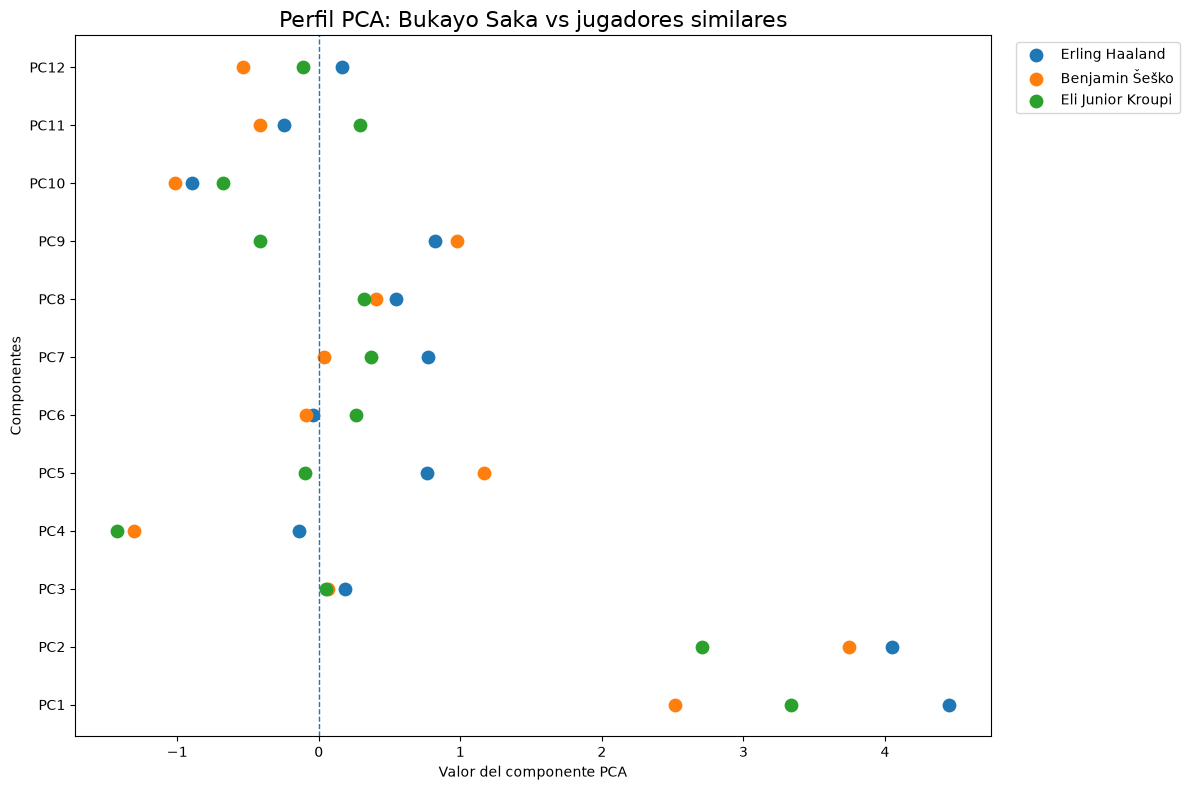

In [33]:
fig, ax = plt.subplots(figsize=(12, 8))

y = np.arange(len(componentes))

# Dibujar cada jugador
for jugador in jugadores:
    ax.scatter(
        datos.loc[jugador, componentes],
        y,
        s=80,
        label=jugador
    )

# Línea vertical en 0
ax.axvline(0, linewidth=1, linestyle="--")

# Ejes
ax.set_yticks(y)
ax.set_yticklabels(componentes)

ax.set_xlabel("Valor del componente PCA")
ax.set_ylabel("Componentes")
ax.set_title(
    "Perfil PCA: Bukayo Saka vs jugadores similares",
    fontsize=16
)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

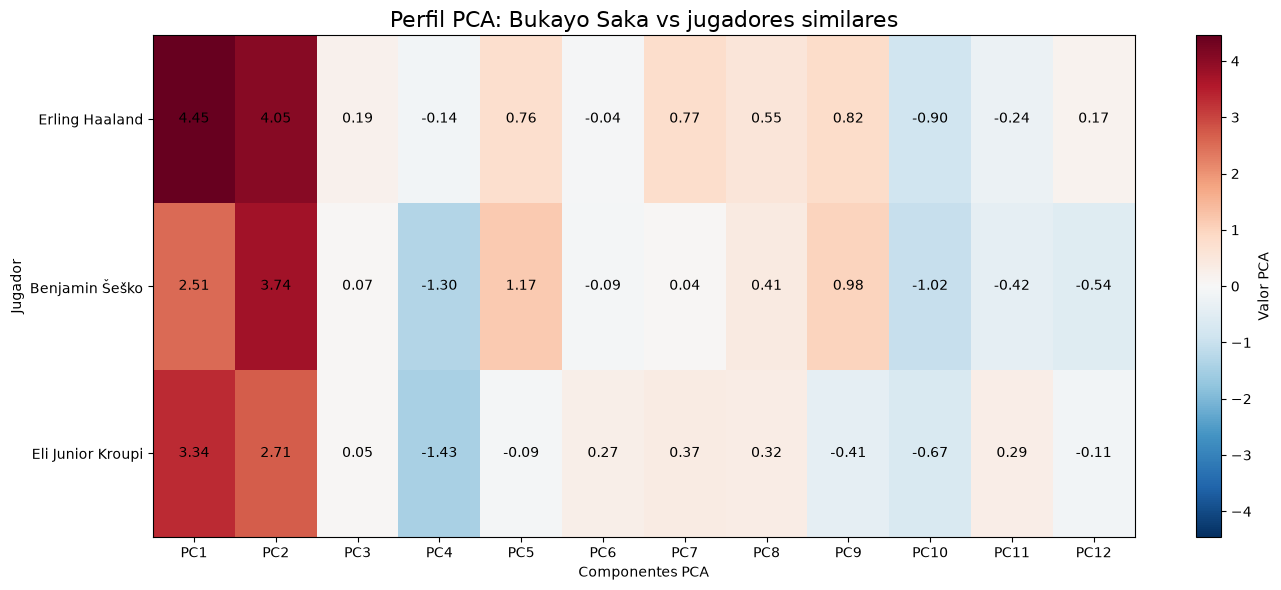

In [40]:
limite = np.abs(datos.values).max()

fig, ax = plt.subplots(figsize=(14, 6))

im = ax.imshow(
    datos.values,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-limite,
    vmax=limite
)

# Eje Y
ax.set_yticks(range(len(jugadores)))
ax.set_yticklabels(jugadores)

# Eje X
ax.set_xticks(range(len(componentes)))
ax.set_xticklabels(componentes)

# Valores
for i in range(len(jugadores)):
    for j in range(len(componentes)):
        valor = datos.iloc[i, j]

        ax.text(
            j,
            i,
            f"{valor:.2f}",
            ha="center",
            va="center"
        )

ax.set_xlabel("Componentes PCA")
ax.set_ylabel("Jugador")

ax.set_title(
    "Perfil PCA: Bukayo Saka vs jugadores similares",
    fontsize=16
)

plt.colorbar(im, ax=ax, label="Valor PCA")

plt.tight_layout()
plt.show()

Como ahora mismo con el standard scanner las variables pueden tner valores negativos, para hacer la representación usamos el minmaxscaler para poder sintetizarlos en valores posiivos.

In [26]:
scaler_radar = MinMaxScaler()

df_pca_minmax = pd.DataFrame(
    scaler_radar.fit_transform(datos),
    index = datos.index,
    columns=datos.columns
)



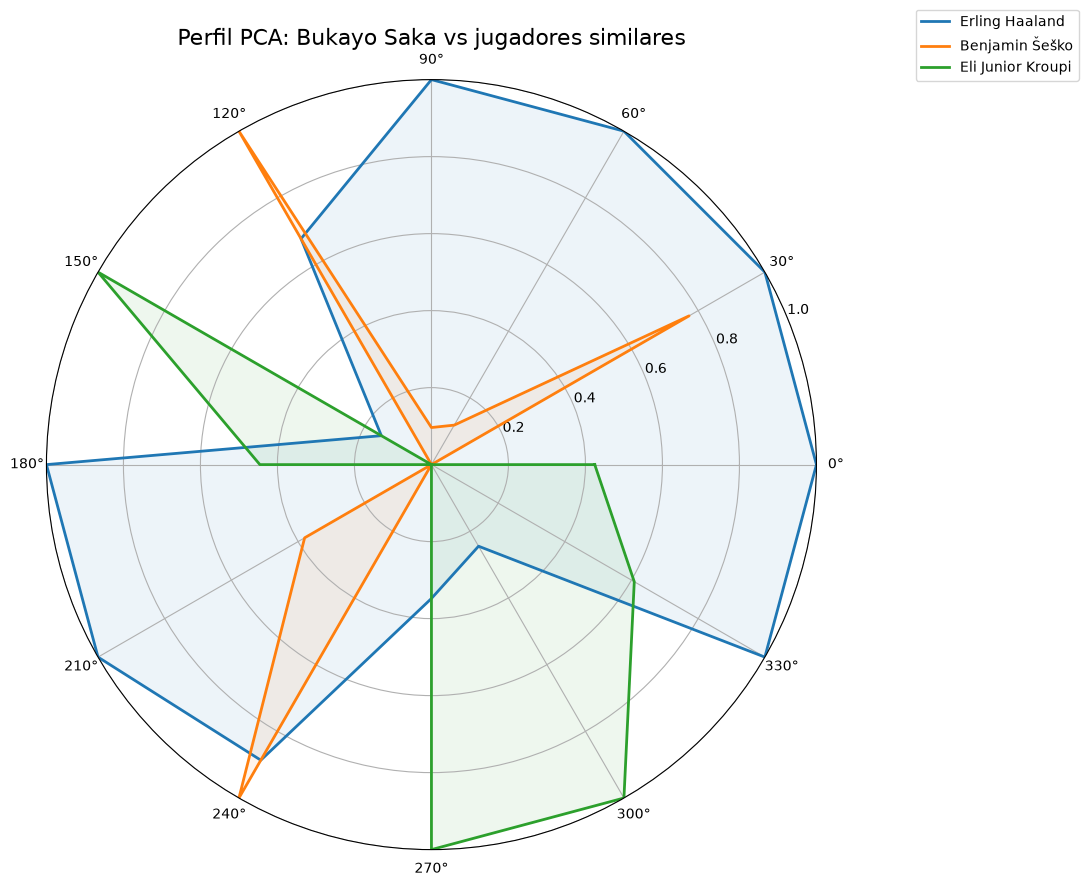

In [27]:
N = len(componentes)

angulos = np.linspace(
    0,
    2 * np.pi,
    N,
    endpoint=False
).tolist()

angulos += angulos[:1]

fig, ax = plt.subplots(
    figsize=(10, 10),
    subplot_kw=dict(polar=True)
)

for jugador in jugadores:

    valores = df_pca_minmax.loc[
        jugador,
        componentes
    ].tolist()

    valores += valores[:1]

    ax.plot(
        angulos,
        valores,
        linewidth=2,
        label=jugador
    )

    ax.fill(
        angulos,
        valores,
        alpha=0.08
    )

ax.set_xticks(angulos[:-1])
#ax.set_xticklabels(etiquetas)

ax.set_ylim(0, 1)

ax.set_title(
    "Perfil PCA: Bukayo Saka vs jugadores similares",
    fontsize=16,
    pad=25
)

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.35, 1.10)
)

plt.show()

## Comparación: similitud coseno vs distancia euclídea

El `MinMaxScaler` de la sección anterior es solo para poder pintar el gráfico de radar (que necesita valores positivos entre 0 y 1); no se usa en el cálculo de similitud. Aquí comparamos, sobre las mismas componentes PCA sin ese reescalado, el ranking que da la similitud coseno (ya calculada arriba) frente al que da la distancia euclídea.

In [28]:
from sklearn.metrics.pairwise import euclidean_distances

saka_euclidean = euclidean_distances(saka, df_pca)

print(saka_euclidean.shape)

(1, 622)


In [29]:
distancia = pd.Series(
    saka_euclidean[0],
    index=df_num.index
)

distancia = distancia.sort_values(ascending=True)  # menor distancia = más parecido
distancia = distancia[distancia.index != "Erling Haaland"]

N_SIMILARES = len(top_5)  # usamos el mismo nº de jugadores que en la comparación por coseno

top_euclidean = distancia.head(N_SIMILARES)
print(top_euclidean)

player
Benjamin Šeško       2.553874
Eli Junior Kroupi    2.775211
dtype: float64


In [30]:
tabla_comparacion = pd.DataFrame({
    "Jugador (Coseno)": top_5.index,
    "Similitud (Coseno)": top_5.values,
    "Jugador (Euclídea)": top_euclidean.index,
    "Distancia (Euclídea)": top_euclidean.values,
})

tabla_comparacion

,Jugador (Coseno),Similitud (Coseno),Jugador (Euclídea),Distancia (Euclídea)
0,Benjamin Šeško,0.919449,Benjamin Šeško,2.553874
1,Eli Junior Kroupi,0.913343,Eli Junior Kroupi,2.775211


In [31]:
coincidencias = set(top_5.index) & set(top_euclidean.index)
print(f"Jugadores que coinciden en ambos métodos: {coincidencias if coincidencias else 'ninguno'}")

Jugadores que coinciden en ambos métodos: {'Eli Junior Kroupi', 'Benjamin Šeško'}
